# Машинное обучение, ФКН ВШЭ

## Практическое домашнее задание 3.1 Базовая генерация признаков

### Общая информация

Дата выдачи: 23.02.2026

Мягкий дедлайн: 12.03.2026 23:59MSK

Жесткий дедлайн: 16.03.2026 23:59MSK

### О задании

В данном задании вы познакомитесь с базовыми подходами для создания новых признаков в табличном машинном обучении. Вам понадобится подумать над тем, зачем мы делаем те или иные преобразования, научиться принимать решения, дающие наилучшие результаты, и узнать, как реализовывать их при помощи библиотек

### Оценивание и штрафы

Каждая из задач имеет определенную «стоимость» (указана в скобках около задачи). Максимально допустимая оценка за эту часть — 6 баллов. Детальнее про оценивание — в самом конце ноутбука.

Сдавать задание после указанного срока сдачи нельзя. При выставлении неполного балла за задание в связи с наличием ошибок на усмотрение проверяющего предусмотрена возможность исправить работу на указанных в ответном письме условиях.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов (подробнее о плагиате см. на странице курса). Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник в отдельном блоке в конце вашей работы (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник).

Неэффективная реализация кода может негативно отразиться на оценке. Также оценка может быть снижена за плохо читаемый код и плохо считываемые диаграммы.

Все ответы должны сопровождаться кодом или комментариями о том, как они были получены.

### Формат сдачи
Задания сдаются через систему Anytask. Инвайт можно найти на странице курса. Присылать необходимо ноутбук с выполненным заданием. Сам ноутбук называйте в формате **homework-practice-03-base-Username.ipynb**, где Username — ваша фамилия.

### **Сетап**

<img style="float: right; padding-right:15px; padding-bottom:10px" src="https://i.postimg.cc/26KqqSb2/pomoika2.png" height=300px width=200px alt="Pomoika 2">
    
В этом домашнем задании мы будем работать с задачей классификации, но сконцентрируемся на том, что приносит не меньшую пользу, чем сами модели — замешиванию данных.

Целевая метрика уже выбрана за нас: мы будем считать $\text{ROC-AUC}$, но не простой, а коэффициент Джини:

$$ \text{Gini} = 2 \cdot \text{ROC-AUC} - 1$$

Конечная цель данного мероприятия — собрать пайплайн машинного обучения от и до, начиная с предобработки данных, заканчивая оптимизацией. При желании это можно доделать до целого пет-проекта, особенно если добавить сбор данных и деплой модели, но в дз этого не будет :(.

Цель конкретно базового ноутбука — познакомить вас с основными преобразованиями и собрать солидный фундамент для преобразований посложнее. 

In [192]:
from sklearn.metrics import roc_auc_score


def gini(y_true, y_score):
    return 2 * roc_auc_score(y_true, y_score) - 1.0

#### **Данные**

У вас на руках (на Kaggle) датасет по широко известной в неузких кругах видеоигре Dota 2, скачанный через OpenDota API и заботливо анонимизированный. Если вы не знакомы с игрой — ничего страшного, все необходимое для заданий в базовой части мы подробно опишем.

Нас интересует исход матча — победа или поражение, исходя из совершенно разных факторов (например, чтобы делать ставки на спорт, осуждаем?). Это информация о сессии, игроках, героях, и т д. **в первые 15 минут** после начала матча.

Краткая сводка об игре:

- Dota 2 — командная игра: 5 игроков за Свет (Radiant) против 5 за Тьму (Dire).
- Каждый игрок управляет уникальным героем со своим набором атрибутов и способностей.
- Цель — снести главную постройку на вражеской базе (в простонародье трон).
- В процессе матча игроки добывают золото и опыт, покупают предметы и убивают противников, чтобы стать сильнее.
- Ничьих не бывает, фиксированного таймера нет — матч длится до падения трона.

#### 📌 **Важнейшее замечание**

Предполагается, что у вас уже сложилось понимание:
- как крутить и вертеть данные, чтобы фиты делались твёрдо, трансформы ложились чётко, шейпы датафреймов стакались и нужные джойны джойнились;
- как рисовать читаемые графики;
- как проверять качество модели;

Пожалуйста, следите за этим очень-очень внимательно, иначе рискуете получить штраф и всеобщее порицание в нашем уютном МО-1 чатике (хотя, у этого есть плюсы).

Если возникнут вопросы по игровой части — **не стесняйтесь** спрашивать, гуглить, обращаться к GPT или, прости Господи, дотерам. Знание области — важнейшая составляющая хорошего фича инжиниринга

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Для лучшего понимания, в голубеньких пунктах будет небольшое <font color="#647cb8">**обоснование**</font> того, зачем вообще делается то или иное преобразование (в колабе придётся включать интуицию, там не работает HTML). Вы можете её скипнуть, если всё понятно и без этого

</div>

<div style="border-left: 5px solid #f68c9d; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

В пунктах с розоватой, как у всеми любимого Pudge, расцветкой мы попросим вас написать <font color="#f68c9d">**Ответ**</font> на <font color="#f68c9d">**Вопрос**</font> или <font color="#f68c9d">**рефлексию**</font>, которая должна направить вашу мысль о том, как варить фичи, в нужном направлении. Уметь аргументировать свою точку зрения важно не менее

Пожалуйста, даже если вы уже прожжённый дед инсайд и дата-сайентист 14 уо, всё равно <font color="#f68c9d">**порефлексируйте**</font>. Количество потерянных нервных клеток и ваш успех на соревновании напрямую зависят от базовой предобработки.
Вы **можете** писать <font color="#f68c9d">**её**</font> ёмко, но только если **знаете** ответ

</div>

<div style="border-left: 5px solid #cb9255; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(200, 156, 105, 0.05);">

<font>По ходу домашки вам придётся делать <font color="#cb9255">**выборы**</font> и подбирать <font color="#cb9255">**гиперпараметры**</font>. Какие-то из них важнее остальных. У ряда выборов последствия чисто номинальные, какие-то видоизменят другие задания, третьи полностью определят, как вы будете делать остальную домашку. 

Принимайте решения мудро. Не привязывайтесь к ним слишком сильно, возможно, в процессе вам захочется пересмотреть ваши жизненные приоритеты. Пробуйте, экспериментируйте, фичи это самое творческое, что есть в машинном обучении

При желании, в конце обоих ноутбуков есть инструменты, которые, при остром желании и избытке свободного времени, могут тупо перебрать все выборы и найти самый оптимальный, но это опционально
</div>

### **Часть 1. Это, так сказать, база. (3.25 балла)** <img align="center" height=28 width=28 src="https://media.tenor.com/5vGX5VO-IxsAAAAi/arthas.gif">

В которой студент учится смотреть на фичи под правильным углом и готовить из сырых данных простые, но аппетитные факторы

#### **Задание 1.1. Датасет** (0.5 балла)

Чтобы начать работу с данными, эти данные сперва нужно [загрузить](https://www.kaggle.com/t/6fd940fbeb1746a78031e5d0277f6105). Пока что нам потребуются лишь:

1. Информация о матчах - `matches_df_train.csv`.
2. Тестовые данные для соревнования - `matches_df_test.csv`.

Посмотрите на все csv-файлы выше, создайте под каждый из них отдельный датафрейм и отметьте (текстом или кодом):
- объемы таблиц: как в Мб, так и `df.shape`
- какие в них есть колонки по своему содержанию

In [193]:
import pandas as pd

matches_df_train = pd.read_csv('/kaggle/input/competitions/dota-2-hse-ml-1-course-competition-2026/matches_df_train.csv')
matches_df_test = pd.read_csv('/kaggle/input/competitions/dota-2-hse-ml-1-course-competition-2026/matches_df_test.csv')


In [194]:
print('matches_df_train.shape:', matches_df_train.shape)
print('matches_df_train size MB:', matches_df_train.memory_usage().sum() / 1024**2)
print(matches_df_train.columns.tolist())
print(matches_df_train.dtypes.astype(str).tolist())

matches_df_train.shape: (641090, 7)
matches_df_train size MB: 29.958288192749023
['match_id', 'date', 'region', 'game_mode', 'duration', 'radiant_win', 'avg_mmr']
['int64', 'object', 'object', 'int64', 'int64', 'bool', 'float64']


In [195]:
print('matches_df_test.shape:', matches_df_test.shape)
print('matches_df_test size MB:', matches_df_test.memory_usage().sum() / 1024**2)
print(matches_df_test.columns.tolist())
print(matches_df_test.dtypes.astype(str).tolist())


matches_df_test.shape: (59748, 5)
matches_df_test size MB: 2.2793312072753906
['match_id', 'date', 'region', 'game_mode', 'avg_mmr']
['int64', 'object', 'object', 'int64', 'float64']


Отдельно хочется посмотреть распределение целевой переменной, покажите его, пожалуйста

In [196]:
print(matches_df_train['radiant_win'].value_counts(normalize=True))


radiant_win
True     0.510772
False    0.489228
Name: proportion, dtype: float64


<div style="border-left: 5px solid #c27985; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** подходящая ли в данном случае метрика $\text{Gini}$ в сравнении, например, с $\text{AUC-PR}$?

**Ответ:**

Целевая переменная здесь примерно сбалансирована, поэтому roc-auc, а значит и  Gini корректно отражают качество модели. auc-pr обычно лучше при сильном дисбалансе классов, когда важна точность предсказания редкого класса.

</div>

чтобы дальше не было проблем с утечкой val в train сразу сделаем val

In [197]:
matches_df_full_train = matches_df_train.sort_values('date').copy()

val_size = int(len(matches_df_full_train) * 0.2)
matches_df_val = matches_df_full_train.iloc[-val_size:].copy()
matches_df_train = matches_df_full_train.iloc[:-val_size].copy()

print(matches_df_train.shape, matches_df_val.shape)

(512872, 7) (128218, 7)


#### **Задание 1.2. Категории** (0.75 балла)

Чтобы построить реально балдёжную модель, зачастую не получится просто написать фит предикт. О нет, это долгая и утомительная возня. А если нужно ещё и отчётики писать, то хоть <span style="color:grey"><font size="1">~~вешайся (осуждаем)~~ </font></span> увольняйся. Так и здесь. И того, что есть, уже хватит, чтобы продемонстрировать глубокую и тёмную сторону Dota Science.

В целом, данные уже содержат признаки, по которым что-то даже можно построить, в частности — регионы.

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

У Radiant, по сравнению с Dire, исторически есть небольшое преимущество — чуть удобнее карта, порядок выбора героев и всё такое. В разных регионах бывают разные предпочтения по стилям игры и тактикам, и где-то это преимущество реализуют лучше

</div>

Посмотрите, где у нас содержится информация о регионе, на серверах которого был проведён матч, и постройте 2 графика:
1) Распределение регионов (процентное и абсолютное) на тренировочных и тестовых данных
2) Среднее значение таргета на трейне, в зависимости от региона

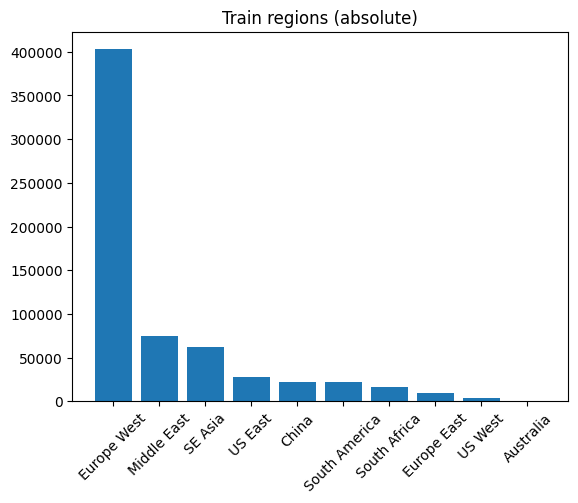

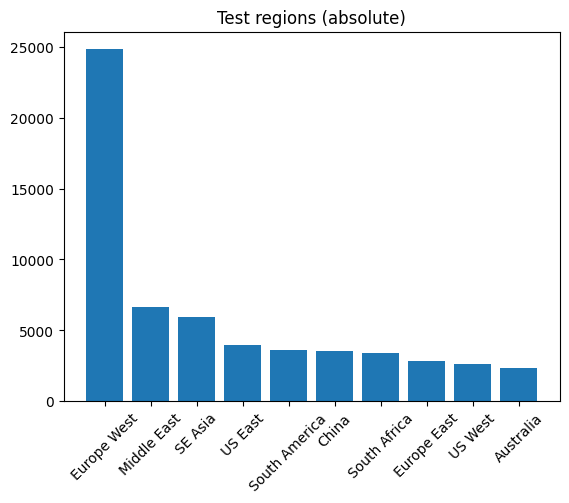

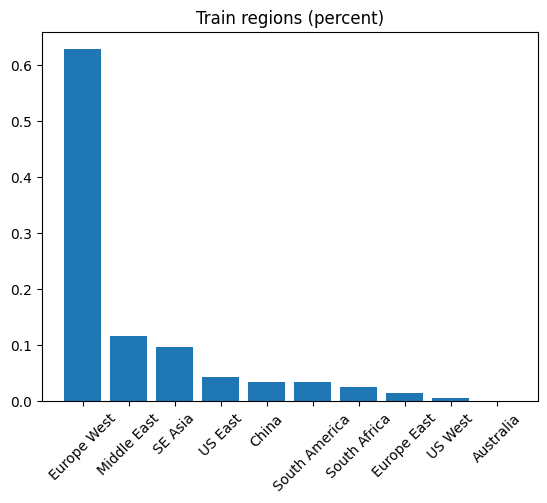

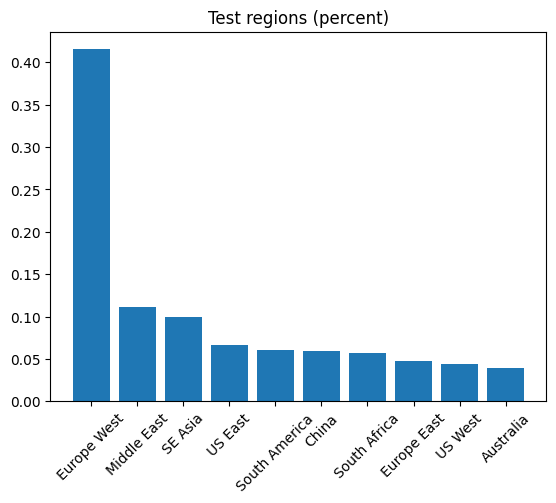

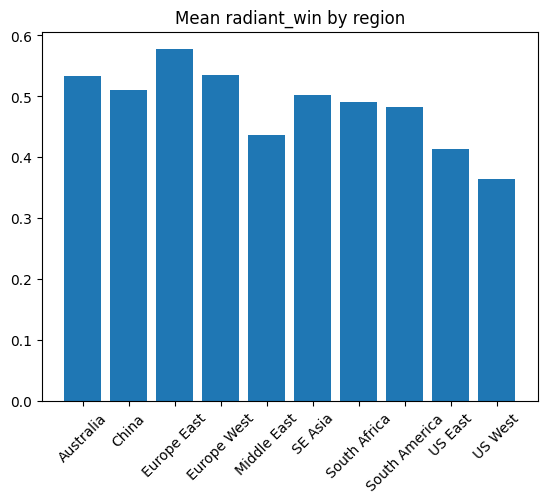

In [198]:
import matplotlib.pyplot as plt

train_region_counts = matches_df_full_train['region'].value_counts()
test_region_counts = matches_df_test['region'].value_counts()

plt.bar(train_region_counts.index, train_region_counts.values)
plt.xticks(rotation=45)
plt.title('Train regions (absolute)')
plt.show()

plt.bar(test_region_counts.index, test_region_counts.values)
plt.xticks(rotation=45)
plt.title('Test regions (absolute)')
plt.show()

plt.bar(train_region_counts.index, train_region_counts.values / train_region_counts.sum())
plt.xticks(rotation=45)
plt.title('Train regions (percent)')
plt.show()

plt.bar(test_region_counts.index, test_region_counts.values / test_region_counts.sum())
plt.xticks(rotation=45)
plt.title('Test regions (percent)')
plt.show()

region_target = matches_df_full_train.groupby('region')['radiant_win'].mean()

plt.bar(region_target.index, region_target.values)
plt.xticks(rotation=45)
plt.title('Mean radiant_win by region')
plt.show()


<div style="border-left: 5px solid #c27985; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** что вы можете сказать о распределении регионов? Объясните, получится ли вообще обучить по нему модель, есть ли там сигнал?

**Ответ:**

Распределение регионов сильно несбалансировано. Большая часть матчей приходится на Europe West, сильно меньше Middle East и SE Asia, остальные еще меньше.
Среднее значение radiant_win различается по регионам, значит регион содержит сигнал о вероятности победы radiant. Однако различия не очень большие, поэтому один признак region будет полезен, но не прям бомба.

</div>

Наша первая развилка — <font color="#cb9255">**выбор**</font>, какой из энкодеров стащить. Рекомендуется брать что-то из `category_encoders`, они похожи на стандартные из `sklearn`, но их больше и применять их проще.

| <font color="#cb9255">**One-Hot Encoder**</font> | <font color="#cb9255">**Target Encoder**</font> |
| :--- | :--- |
| Превращает категориальный признак в вектор из 0 и 1.  <br> 1 стоит на месте i‑го индекса, если у объекта есть i‑е значение признака. | Кодирует категориальный признак средним значением таргета.  <br> Среднее считается по всем объектам с i‑м значением признака. |

Можно взять и другой, но морально готовьтесь получить $\text{Gini} = 0$
</div>

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Без энкодинга использовать категориальные признаки в линейных моделях, увы, нельзя, выбор без выбора 

</div>

In [199]:
#!pip install -qU category-encoders
import category_encoders

<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** какой из энкодеров кажется вам наиболее привлекательным? Почему?

**Ответ:**

Target encoder, потому что он кодирует категории средним значением таргета, поэтому напрямую показывает связь признака с целевой переменной и не увеличивает размерность данных, как one hot encoder.

</div>

Закодируйте колонку `region` выбранным вами способом

In [200]:
enc = category_encoders.TargetEncoder()

matches_df_train['region_encoded'] = enc.fit_transform(matches_df_train['region'], matches_df_train['radiant_win'])
matches_df_val['region_encoded'] = enc.transform(matches_df_val['region'])
matches_df_test['region_encoded'] = enc.transform(matches_df_test['region'])


#### **Задание 1.3. Даты** (1.25 балла)

Если нам хочется видеть будущее, именно время диктует, что брать можно, а что никак нельзя

Найдите колонку дат на тренировочных данных и:
1. Постройте график доли побед Radiant в зависимости от даты матча
2. Сравните временные диапазоны на трейне и тесте

In [201]:
print(matches_df_train['date'].min(), matches_df_train['date'].max())
print(matches_df_val['date'].min(), matches_df_val['date'].max())
print(matches_df_test['date'].min(), matches_df_test['date'].max())


2024-01-01 2024-09-25
2024-09-25 2024-11-30
2024-12-01 2024-12-31


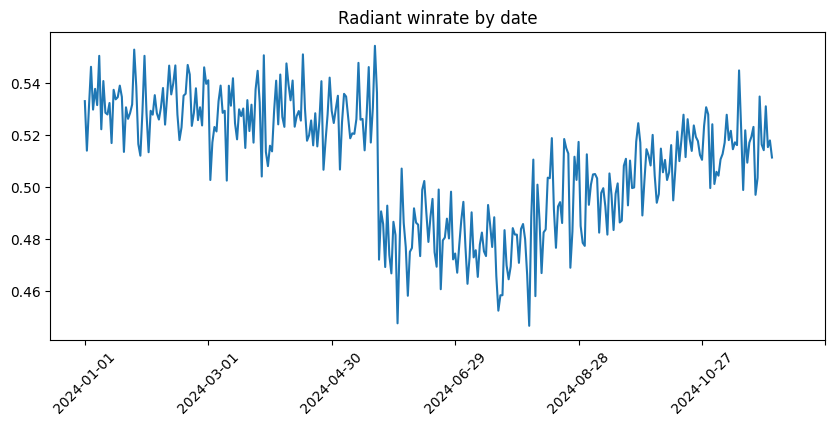

In [202]:
daily_winrate = matches_df_full_train.groupby('date')['radiant_win'].mean()

plt.figure(figsize=(10, 4))
plt.plot(daily_winrate.index, daily_winrate.values)
plt.title('Radiant winrate by date')
plt.xticks(rotation=45)
plt.xticks(range(0, 365, 60))
plt.show()


<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** видите ли вы какой-то паттерн в распределении дат? Можете ли вы объяснить при помощи сети Интернет, что там произошло? \
(Подсказка: соревновательные игры периодически обновляются)

**Ответ:**

Очень сильная просадка побед Radiant около мая 2024. Гугл поиск ассистент сказал: В мае 2024 года в Dota 2 вышли важные обновления, связанные с выходом масштабного патча 7.36 (в конце мая), который ввел врожденные способности и аспекты для всех героев. Ключевые изменения включали корректировку баланса, исправление багов после крупного апдейта, изменения в ивенте «Павшая корона» и визуальные улучшения. 

</div>

Теперь давайте что-нибудь повыделяем.

<div style="border-left: 5px solid #5584a8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Даты сами по себе это всегда очень простые фичи, функционал есть в любой библиотеке. Связь с таргетом может быть, но не обязана. Именно даты проверить легко и быстро, зависимости бывают неожиданными. Впрочем, это не единственная причина, не переключайтесь

</div>

С таймстемпом можно делать не так много, кроме базовых манипуляций:

1. Вытащите лежащую на поверхности информацию, например, день и день недели. Хватит и этих двух
2. Посмотрите сами на список возможных признаков, будь то [pandas](https://pandas.pydata.org/docs/user_guide/timeseries.html#time-date-components) или [polars](https://docs.pola.rs/api/python/stable/reference/expressions/temporal.html), и <font color="#cb9255">**либо добавьте**</font> 2 признака, которые, как вам кажется, сработают, <font color="#cb9255">**либо поясните**</font>, почему это ничего не даст

<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** необходимо ли кодировать признаки из дат? Если да, то какие и как? Если нет, то почему? </font>

**Ответ:** 

Признаки из дат ниже получились очень неинформативные. radiant win колеблется около 0.5 прям очень близко, что говорит о полной бесполезности этих признаков из дат. Это в целом логично, потому что сильной разницы силы состава игроков за Radiant и за других нет в разные дни недели.

</div>

3. Закодируйте новые признаки, согласно вашему ответу

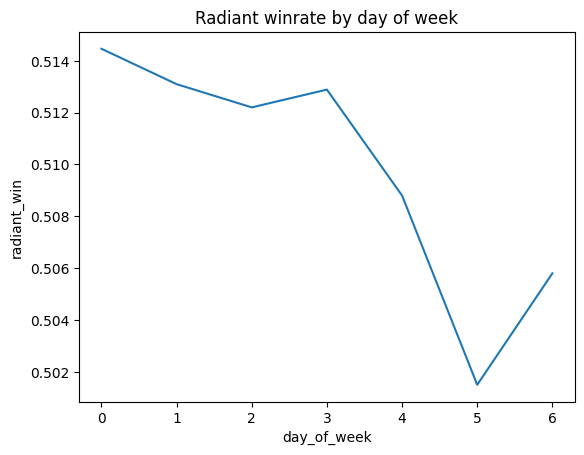

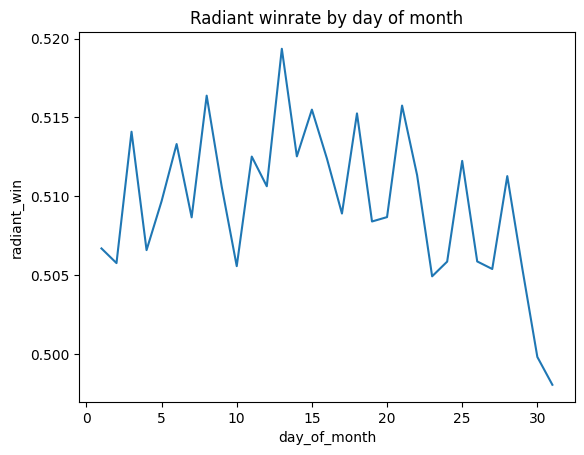

In [203]:
for df in [matches_df_train, matches_df_val, matches_df_test]:
    df['date'] = pd.to_datetime(df['date'])
    df['day_of_week'] = df['date'].dt.dayofweek
    df['day_of_month'] = df['date'].dt.day

day_of_week_target = matches_df_train.groupby('day_of_week')['radiant_win'].mean()
day_of_month_target = matches_df_train.groupby('day_of_month')['radiant_win'].mean()

plt.plot(day_of_week_target.index, day_of_week_target.values)
plt.title('Radiant winrate by day of week')
plt.xlabel('day_of_week')
plt.ylabel('radiant_win')
plt.show()

plt.plot(day_of_month_target.index, day_of_month_target.values)
plt.title('Radiant winrate by day of month')
plt.xlabel('day_of_month')
plt.ylabel('radiant_win')
plt.show()


Кажется, мы что-то забыли... Ах да, надо бы и модель обучить, вот только без валидации это будет как-то не по-моповски, надо озаботиться этим вопросом.

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

На самом деле временная структура нужна не столь, чтобы вытащить какие-то признаки, сколько, чтобы понять распределение и изменение данных во времени же. Даты играют в этом прямую роль

</div>

<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** почему здесь будет не лучшим решением брать случайное разбиение на трейн и валидацию?

**Ответ:**

Случайное разбиение плохой вариант, потому что данные имеют временную зависимость (особенно с этим обновлением в мае 2024). При случайном разбиении в train и validation попадут матчи из одних и тех же периодов, в том числе после одних и тех же патчей, из-за чего оценка качества может получиться слишком хорошей.

</div>

Тут выбор у вас решили отобрать, делать мы будем OOT валидацию. Впрочем, какие-то опции ещё остались

<table width="800" border="1" cellpadding="8" cellspacing="0">
  <tr>
    <th width="50%">
      <font color="#cb9255">OOT (Out-of-Time)</font>
    </th>
    <th width="50%">
      <font color="#cb9255">CV OOT (Cross-Validation Out-of-Time)</font>
    </th>
  </tr>
  <tr>
    <td valign="top">
      Валидация с одной отложенной подвыборкой, <br>
      взятой после трешхолда t. Простая, как палка, <br>
      но если валидация получится грустной — <br>
      аномальной, нетипичной, маленькой, — <br>
      то и метрика ваша тоже будет грустной.
    </td>
    <td valign="top">
      Кросс-валидация с k разбиениями по времени <br>
      с итеративным расширением исходного фолда. <br>
      Оценка метрики сместится куда меньше <br>
      по сравнению с плохим сплитом OOT, <br>
      но это долго, если фолдов много.
    </td>
  </tr>
  <tr>
    <td valign="top">
      <code>sklearn.model_selection.train_test_split</code>
    </td>
    <td valign="top">
      <code>sklearn.model_selection.TimeSeriesSplit</code>
    </td>
  </tr>
</table>



Настройте любой из видов валидации (<font color="#cb9255">**трешхолд**</font> `t` или <font color="#cb9255">**число фолдов**</font> <code>n_folds</code></font> подберите сами). Они оба должны показывать качество адекватно, хотя второй теоретически должен быть более обоснован. CV-OOT не даст вам бонусов, но кто знает, за какие крохи Джини придётся бороться на соревновании?

валидация уже сделана в задании 1.1, чтобы не было утечек регионов и дат

In [204]:
print(matches_df_train.shape)
print(matches_df_val.shape)


(512872, 10)
(128218, 10)


И вот теперь мы уже наконец-то будем что-то обучать. Моделей классификации мы знаем как минимум две — SVM и логистическую регрессию, но есть нюанс.

Выборы, выборы..:

<table width="800" border="1" cellpadding="8" cellspacing="0">
  <tr>
    <th width="50%">
      <font color="#cb9255">Dedicated model</font>
    </th>
    <th width="50%">
      <font color="#cb9255">Gradient Descent</font>
    </th>
  </tr>
  <tr>
    <td valign="top">
      Большой разницы между <code>LogisticRegression</code> и <code>LinearSVC</code> <br>
      из <code>sklearn.linear_model</code> на самом деле нет: <br>
      разделяющие поверхности очень похожи, <br>
      оба хорошо оптимизированы специальными солверами.
    </td>
    <td valign="top">
      Градиентный спуск через <code>sklearn.linear_model.SGDClassifier</code> <br>
      с параметрами <code>loss="log_loss"</code> или <code>loss="hinge"</code> — <br>
      очень соблазнительная альтернатива, но!
    </td>
  </tr>
  <tr>
    <td valign="top">
      <font color="#cb9255"><b>+</b></font> Обучать и применять их в разы проще, <br>
      фит–предикт делает брр. <br>
      <font color="#cb9255"><b>−</b></font> Они используют сразу всю выборку <br>
      для обучения, а в ходе задания наша выборка <br>
      может вырасти раз так в 1000, немало!
    </td>
    <td valign="top">
      <font color="#cb9255"><b>+</b></font> Влезет любой датасет. <br>
      <font color="#cb9255"><b>+</b></font> Бóльший контроль над процессом обучения. <br>
      <font color="#cb9255"><b>−</b></font> Обучать на больших данных <br>
      (скорее про часть <b>advanced</b>) придётся через <code>partial_fit</code>, неудобно. <br>
      <font color="#cb9255"><b>−</b></font> Нужно подбирать больше гиперпараметров.
    </td>
  </tr>
</table>


Выберите <font color="#cb9255">**одну из**</font> моделей выше (хотя `LinearRegression` <font color="#cb9255">**тоже можно**</font>, если у вас сегодня авантюрное настроение, успех не гарантирован, о рисках узнаете на лекции) **(обращаем внимание, что другие варианты запрещены)**. Обучите по одному экземпляру на группах признаков:

- дат
- регионов
- дат и регионов

Ну и замерьте качество!

<font color="#cb9255">**NB**</font>: 

1. Вы сразу можете строить роскошный пайплайн обучения, а не делать по кускам в отдельных блоках, про это есть **advanced** пункт (**6.1**) на 0.5 баллов
2. Если у вас есть GPU, то почему бы его и не [использовать](https://docs.rapids.ai/api/cuml/stable/)? Если гпу у вас нет, у вас теперь точно есть Kaggle, который щедро дарит 30 часов гпу в неделю, пользуйтесь на здоровье, за это есть маленький, но приятный буст на 0.25 балла (**пункт 6.3**)
3. Наконец, если вы сразу оформите хранилище для результатов запусков ваших моделей, вы снова получите 0.25 балла (**пункт 6.2**)

In [208]:
from sklearn.linear_model import LogisticRegression
import numpy as np

X_dates_train = matches_df_train[['day_of_week', 'day_of_month']]
X_dates_val = matches_df_val[['day_of_week', 'day_of_month']]

X_region_train = matches_df_train[['region_encoded']]
X_region_val = matches_df_val[['region_encoded']]

X_both_train = matches_df_train[['day_of_week', 'day_of_month', 'region_encoded']]
X_both_val = matches_df_val[['day_of_week', 'day_of_month', 'region_encoded']]

y_train = matches_df_train['radiant_win']
y_val = matches_df_val['radiant_win']

def get_score(X_train, y_train, X_val, y_val):
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)
    val_preds = model.predict_proba(X_val)[:, 1]
    return gini(y_val, val_preds)

print('dates val gini:', get_score(X_dates_train, y_train, X_dates_val, y_val))
print('region val gini:', get_score(X_region_train, y_train, X_region_val, y_val))
print('dates+region val gini:', get_score(X_both_train, y_train, X_both_val, y_val))


dates val gini: 0.002595834783931439
region val gini: 0.07406392024851782
dates+region val gini: 0.07571301423694798


<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** помогли ли даты? А должны? Хотите ли вы их оставить?

**Ответ:**

Даты почти не помогли: gini примерно 0.0025, что близко к случайному уровню. Регион даёт заметно больший баф (примерно 0.074), а добавление дат увеличивает качество совсем незначительно.
Это ожидаемо, потому что, как я раньше писала, день недели и день месяца вряд ли напрямую связаны с исходом матча. Поэтому давайте уберем эти признаки.

</div>

In [209]:
matches_df_train = matches_df_train.drop(columns=['day_of_week', 'day_of_month'])
matches_df_val = matches_df_val.drop(columns=['day_of_week', 'day_of_month'])
matches_df_test = matches_df_test.drop(columns=['day_of_week', 'day_of_month'])


#### **Задание 1.4. Числа** (0.75 балла)

Остался неотвеченным лишь один вопрос — а что числовые признаки? С ними всё одновременно и проще, и сложнее.

Найдите, где хранится средний ммр матча — это средний рейтинг игроков, которые в нём участвовали, чем выше, тем лучше.

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

От ммра напрямую зависит то, как игроки пользуются естественным преимуществом Radiant. Чем игроки сильнее, тем чаще это должно происходить, в теории

</div>

Сделайте (на трейне, валидации и тесте) вот что :
1. Постройте график распределения ммров
2. Сравните, насколько распределения похожи между собой визуально

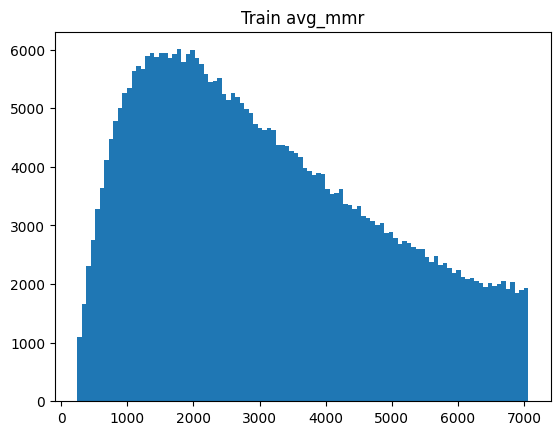

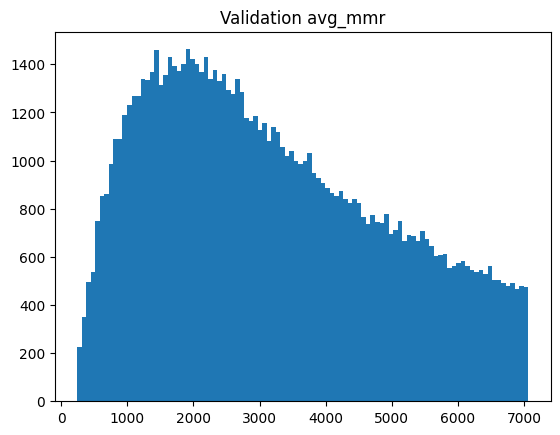

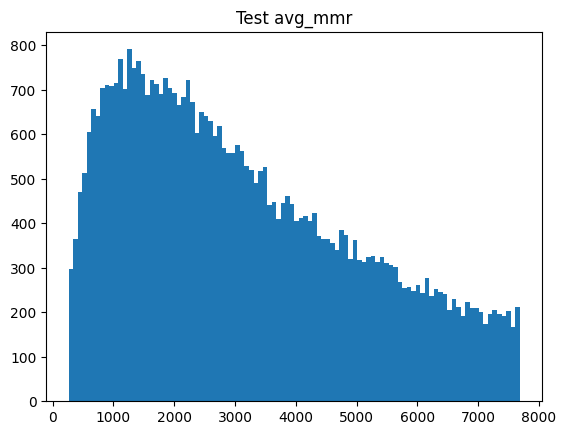

In [210]:
plt.hist(matches_df_train['avg_mmr'], bins=100)
plt.title('Train avg_mmr')
plt.show()

plt.hist(matches_df_val['avg_mmr'], bins=100)
plt.title('Validation avg_mmr')
plt.show()

plt.hist(matches_df_test['avg_mmr'], bins=100)
plt.title('Test avg_mmr')
plt.show()


Распределения между собой очень похожи

<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** как бы вы описали это распределение в целом, похоже ли оно на что-то знакомое вам? 

**Ответ:**

Распределение с тянущимся хвостом и пиком около 0. похоже на экспоненциальное распределение.

</div>

Кто-то где-то говорил, что числовые признаки надо бы стандартизировать, чтобы вышло что-то годное. Этот кто-то прав, но как известно, практика — критерий истины

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Но в действительности это зависит от данных. Сходимость итеративных алгоритмов улучшается, но может пострадать качество, особенно, если распределение не нормальное, или есть отличие в $\mu$ и $\sigma$ на тесте
 
Однако даже пара пунктов Джини это довольно хороший буст, вы убедитесь, когда приступите к сореве, за них нужно бороться любой ценой, тем более, что это почти бесплатно

</div>

Так или иначе, у нас и распределение то не нормальное, но, к счастью, это решаемо. Сделайте такие преобразования признака ммров $f_{\text{mmr}}$ и нарисуйте их график:

$$f_{\text{mmr}} \mapsto \log( 1+f_{\text{mmr}} ); \qquad f_{\text{mmr}} \mapsto \sqrt{f_{\text{mmr}}}; \qquad f_{\text{mmr}} \mapsto \frac{1}{1+f_{\text{mmr}}}; \qquad f_{\text{mmr}} \mapsto \exp{\log f_{\text{mmr}}};$$

Затем выберите то, что вам нравится больше всего

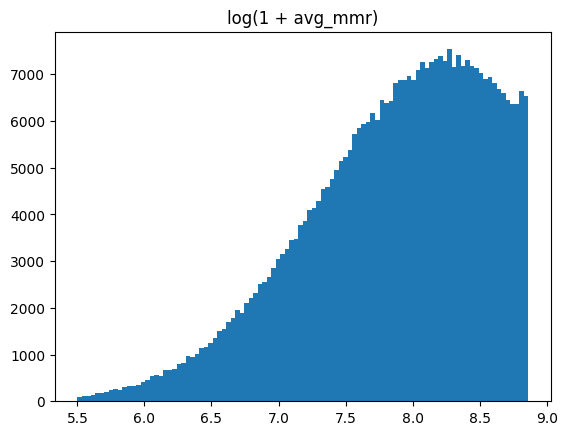

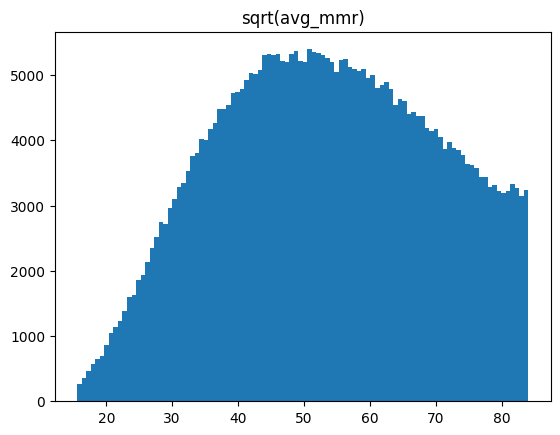

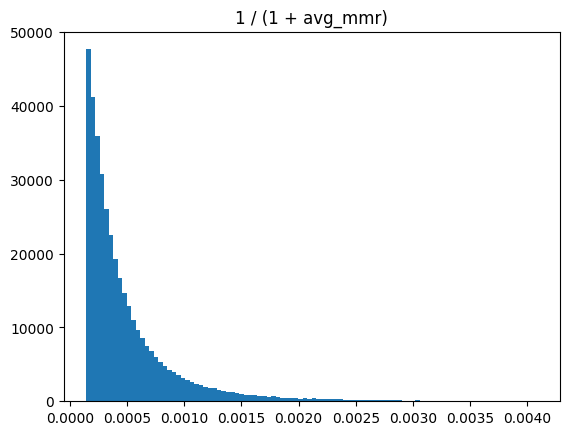

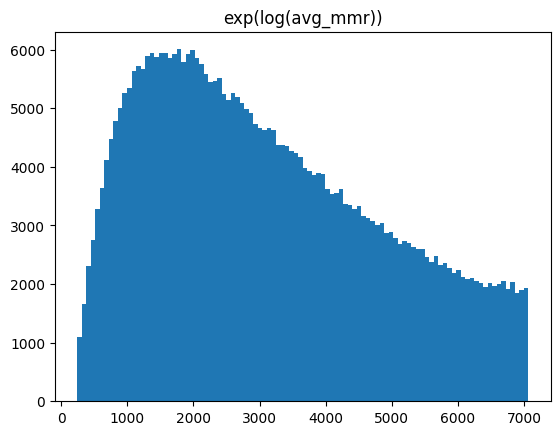

In [211]:
plt.hist(np.log(1 + matches_df_train['avg_mmr']), bins=100)
plt.title('log(1 + avg_mmr)')
plt.show()

plt.hist(np.sqrt(matches_df_train['avg_mmr']), bins=100)
plt.title('sqrt(avg_mmr)')
plt.show()

plt.hist(1 / (1 + matches_df_train['avg_mmr']), bins=100)
plt.title('1 / (1 + avg_mmr)')
plt.show()

plt.hist(np.exp(np.log(matches_df_train['avg_mmr'])), bins=100)
plt.title('exp(log(avg_mmr))')
plt.show()

In [212]:
matches_df_train['sqrt_avg_mmr'] = np.sqrt(matches_df_train['avg_mmr'])
matches_df_val['sqrt_avg_mmr'] = np.sqrt(matches_df_val['avg_mmr'])
matches_df_test['sqrt_avg_mmr'] = np.sqrt(matches_df_test['avg_mmr'])


Мы как-то раньше не обращали внимание, но шестое чувство подсказывает, что в ммрах есть пропуски. Выкинуть их не получится, потому что на тесте они тоже есть, поэтому выход один — чем-то заполнять. 

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

А пропуски у нас есть, потому что не все игры рейтинговые, там информацию по ммру собрать не удастся

В категориальных признаках пропуски не так важны для линрега, их можно закодировать специальной категорией. В числовых проигнорировать их не получится

В любом случае, лучше дополнительно добавить признак-флаг `mmr_missing`, который говорит, что пропуск там на самом деле есть. <font color="#cb9255">**Можете**</font> замерить его влияние, если есть желание, вдруг мы советуем полную дичь и там Джини 0.9?

</div>

<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** нормально ли в данном случае заполнить пропуски нулём? А чем тогда, если нет?

**Ответ:**

Заполнять пропуски нулём не очень хорошая идея, потому что avg_mmr = 0 не имеет реального смысла и модель будет думать что у игрока просто очень низкий рейтинг.
Лучше заполнять пропуски средним значением avg_mmr, а сам факт пропуска учитывать отдельным признаком mmr_missing

</div>

Момент истины. Обучите две новые модели: к оптимальному набору фичей из предыдущего пункта добавьте в одном случае фичу без преобразования, а в другом — после преобразования. Зацените эффект на трейне и на валидации

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Помните, что как бы ни было прекрасно и информативно преобразование в вашей голове, ключевое это перформанс на отложенной выборке \
В жизни каждого дата-сайентиста бывает такое, что фича, которая ну должна быть клёвой, <i>математически</i>, на практике оказывается той ещё жижей, и такое, увы, тоже нужно отслеживать

</div>

In [214]:
X_bad_mmr_train = matches_df_train[['region_encoded', 'avg_mmr']].copy()
X_bad_mmr_val = matches_df_val[['region_encoded', 'avg_mmr']].copy()

X_bad_mmr_train['is_nan_mmr'] = X_bad_mmr_train['avg_mmr'].isna()
X_bad_mmr_val['is_nan_mmr'] = X_bad_mmr_val['avg_mmr'].isna()

train_mean = X_bad_mmr_train['avg_mmr'].mean()
X_bad_mmr_train['avg_mmr'] = X_bad_mmr_train['avg_mmr'].fillna(train_mean)
X_bad_mmr_val['avg_mmr'] = X_bad_mmr_val['avg_mmr'].fillna(train_mean)

X_good_mmr_train = matches_df_train[['region_encoded', 'sqrt_avg_mmr']].copy()
X_good_mmr_val = matches_df_val[['region_encoded', 'sqrt_avg_mmr']].copy()

X_good_mmr_train['is_nan_mmr'] = X_good_mmr_train['sqrt_avg_mmr'].isna()
X_good_mmr_val['is_nan_mmr'] = X_good_mmr_val['sqrt_avg_mmr'].isna()

train_mean = X_good_mmr_train['sqrt_avg_mmr'].mean()
X_good_mmr_train['sqrt_avg_mmr'] = X_good_mmr_train['sqrt_avg_mmr'].fillna(train_mean)
X_good_mmr_val['sqrt_avg_mmr'] = X_good_mmr_val['sqrt_avg_mmr'].fillna(train_mean)

y_train = matches_df_train['radiant_win']
y_val = matches_df_val['radiant_win']

print('without transforms val gini:', get_score(X_bad_mmr_train, y_train, X_bad_mmr_val, y_val))
print('with transforms val gini:', get_score(X_good_mmr_train, y_train, X_good_mmr_val, y_val))


without transforms val gini: 0.14749331116829412
with transforms val gini: 0.14839262425307442


In [215]:
train_mean = matches_df_train['sqrt_avg_mmr'].mean()

matches_df_train['is_nan_mmr'] = matches_df_train['sqrt_avg_mmr'].isna()
matches_df_train['sqrt_avg_mmr'] = matches_df_train['sqrt_avg_mmr'].fillna(train_mean)

matches_df_val['is_nan_mmr'] = matches_df_val['sqrt_avg_mmr'].isna()
matches_df_val['sqrt_avg_mmr'] = matches_df_val['sqrt_avg_mmr'].fillna(train_mean)

matches_df_test['is_nan_mmr'] = matches_df_test['sqrt_avg_mmr'].isna()
matches_df_test['sqrt_avg_mmr'] = matches_df_test['sqrt_avg_mmr'].fillna(train_mean)


### **Часть 2. Векторы** (1.5 балла) <img align="center" height=28 width=28 src="https://static.wikia.nocookie.net/dota2_gamepedia/images/1/17/Emoticon_sick.gif/revision/latest?cb=20180504011850">

В которой студент испытывает вьетнамские флешбеки от дз1, фиксит чужие баги и делает нереально мощную фичу, которую можно полировать до посинения

#### **Задание 2.1. Большая чистка** (0.75 балла)

Пока что мы никак не использовали информацию про героев, а ведь от них напрямую зависит исход матча, их больше 100 штук и все они разные: кто-то сильнее, кто-то слабее, а кто-то красивее :3. Только в данные кто-то нагадил, придётся убирать! Тут придётся ещё разочек освежить `pandas`/`polars`

Датасеты, которые нас интересуют теперь — `player_df.csv` и `Constants.Heroes.csv`. Там есть и данные на трейне, и на тесте, мы их обязательно приджойним, но потом.

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Данные, как и стойло, необходимо чистить. Ранее нам везло и в целом каких-то извращений мы не наблюдали, да и тут сходу не увидим. Т.н. *"выбросы"* это, во-первых, тема отдельного холивара, а во-вторых история про доменное несоответствие, матстат такое не найдёт, но на то у нас есть мозг, верно?

Под доменом имеется в виду контекст, в котором создаются ваши данные, и процессы которого ваши данные описывают (в нашем случае — то, как устроена игра и баланс в ней). Тогда выброс — это то, что в контекст не вписывается, даже если ошибки там нет. Про это весь пункт

</div>

Первое, что нужно отсмотреть - главные ключи. Начнём с игроков. Повертите `account_id`, вас должны смутить как минимум два айдишника.

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Не все игроки делают свой профиль публичным, их айди в таком случае будет анонимизирован

Небольшая часть данных собрана некорректно, айди таких игроков тоже помечен особенным значением

</div>

In [217]:
player_df = pd.read_csv('/kaggle/input/competitions/dota-2-hse-ml-1-course-competition-2026/player_df.csv')
constants_heroes_df = pd.read_csv('/kaggle/input/competitions/dota-2-hse-ml-1-course-competition-2026/Constants.Heroes.csv')

In [218]:
player_df['account_id'].value_counts().head(10)

account_id
 4294967295    2795673
-1               27267
 37619671          801
 84244723          763
 87266522          761
 38584608          752
 85427446          743
 62933415          742
 151993649         740
 137331734         735
Name: count, dtype: int64

смутили айдишники -1 и 4294967295

<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** можем ли мы себе позволить выкинуть матчи с какими-либо подозрительными айди без большого ущерба данным?

**Ответ:**

Нет, очень много данных у нас тогда полетит в помойку, и исказит реально распределение данных.

</div>

Следующий логический шаг — одинаковых героев быть в одном матче не должно.  

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

В кастомных, т.е. не основных режимах игры, это может быть не так, но нас они не интересуют

</div>

Найдите, есть ли игры, в которых это по какой-то причине не так. Если таких матчей не слишком много, избавьтесь от них

In [219]:
dup_heroes = player_df.groupby('match_id')['hero_id'].nunique()
bad_matches = dup_heroes[dup_heroes < 10].index
len(bad_matches)

3982

их немного

In [220]:
player_df = player_df[~player_df['match_id'].isin(bad_matches)]

Вы могли заметить героя-импостера под индексом 0. Если вы посмотрите в `Constants.Heroes.csv`, то его там не найдёте, потому что это тоже ошибка.

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Скорее всего это те, кто не успел выбрать героя, игра могла просто не начаться

Вряд ли у нас получится заполнить пропуски чем-то адекватным — они зависят от игрока и героя, переменных много. Попробовать можно, но точно не в базовой части

</div>

Финальным аккордом:

- посмотрите, что за игроки играли на герое с `hero_id=0`, и выкиньте такие матчи вместе со всеми пропусками
- найдите игроков, которые в одном матче играли одновременно и за команду сил Тьмы (слоты `{128, ..., 132}`), и за команду сил Света (слоты `{0, ..., 4}`), не являясь подозрительными айди из пункта выше, уберите их
- отфильтруйте `player_df`, оставьте только те матчи, которые есть в наших выборках
- проверьте, что в каждом матче ровно 5 игроков за Свет и ровно 5 за Тьму

Можно в любом порядке, но эти вещи нужно проверить, они поломают следующий пункт

In [221]:
hero0_matches = player_df.loc[player_df['hero_id'] == 0, 'match_id'].unique()
player_df = player_df[~player_df['match_id'].isin(hero0_matches)]

In [222]:
tmp = player_df[~player_df['account_id'].isin([-1, 4294967295])].copy()
tmp['side'] = tmp['player_slot'] >= 128

both_side_matches = tmp.groupby(['match_id', 'account_id'])['side'].nunique().reset_index()
both_side_matches = both_side_matches[both_side_matches['side'] > 1]['match_id'].unique()

print(len(both_side_matches))
player_df = player_df[~player_df['match_id'].isin(both_side_matches)]

0


In [223]:
all_matches = set(matches_df_train['match_id']) | set(matches_df_val['match_id']) | set(matches_df_test['match_id'])
player_df = player_df[player_df['match_id'].isin(all_matches)]

all_matches_df = pd.DataFrame({'match_id': list(all_matches)})
cnt_radiant = player_df[player_df['player_slot'] < 128].groupby('match_id').size().reset_index(name='cnt_radiant')
cnt_dire = player_df[player_df['player_slot'] >= 128].groupby('match_id').size().reset_index(name='cnt_dire')

all_matches_df = all_matches_df.merge(cnt_radiant, on='match_id', how='left')
all_matches_df = all_matches_df.merge(cnt_dire, on='match_id', how='left')


In [224]:
all_matches_df = all_matches_df[(all_matches_df['cnt_radiant'] == 5) & (all_matches_df['cnt_dire'] == 5)]

In [225]:
player_df = player_df[player_df['match_id'].isin(all_matches_df['match_id'])]
matches_df_train = matches_df_train[matches_df_train['match_id'].isin(all_matches_df['match_id'])]
matches_df_val = matches_df_val[matches_df_val['match_id'].isin(all_matches_df['match_id'])]


In [226]:
len(matches_df_train)


512038

In [227]:
len(matches_df_val), len(matches_df_test)


(127992, 59748)

Если вас всё же одолевает паранойя, то ~~я вас понимаю~~ будьте уверены, что если проблемы в `player_df` и остались, на модель они повлияют минимально. Ну а идеала не бывает нигде

#### **Задание 2.2. Энкодер героев** (0.75 балла)

А зачем мы вообще этим занимаемся? Вопрос хороший. План был в том, чтобы закодировать комбинации героев, которые участвуют в матче. Это чуть более сложный признак, чем обычный трансформ, тут придется поколдовать.

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Идея в том, что какие-то комбинации героев эффективнее других. Если понять, что в матче за персонажи, можно сразу же прикинуть шансы на победу одной из сторон

</div>

Ваша задача - закодировать каждый матч вектором вида:

| match_id | hero_1 | hero_2 | hero_3 | ... | hero_n |
| --- | --- | --- | --- | --- | --- |
| 228 | 1 | 0 | -1 | ... | 0 |

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Потом <font color="#cb9255">**можно**</font> бахнуть One-Hot и разбить героев на две команды, если не боитесь переобучения. Вещь необязательная

</div>

Потребуются таблицы `player_df.csv` и `matches_df_*.csv`. Для удобства может пригодиться `Constants.Heroes.csv` (индексы оттуда и в `player_df` верные, по ним можно джойнить, но они идут не по порядку, не смотрите на пандасовский айди).

Хочется видеть либо функцию, либо в идеале класс, который вертит фичами вот так:

Каждый элемент в векторе матча `(hero_1, ..., hero_n)` принимает значение 1, если герой был в команде сил Света (слоты `{0, ..., 4}`), и -1, если в команде сил Тьмы (слоты `{128, ..., 132}`). 

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Класс нужен, поскольку при неаккуратной реализации есть риск не влезть в память при трансформе целого датасета. Главное, чтобы была функция, а там можно применять её на батч. 

Либо же <font color="#cb9255">**можете**</font> преисполниться спарс матрицами, которые экономно (не) хранят миллионы нулей. Вещь несложная и полезная

</div>

Реализуйте то, что написано

In [228]:
class HeroesEncoder:
    def fit(self, X, y=None):
        self.hero_ids = np.sort(X['hero_id'].unique())
        self.hero_to_col = {hero_id: i for i, hero_id in enumerate(self.hero_ids)}
        self.columns = [f'hero_{hero_id}' for hero_id in self.hero_ids]
        return self

    def transform(self, X, y=None):
        match_ids = np.sort(X['match_id'].unique())
        match_to_row = {match_id: i for i, match_id in enumerate(match_ids)}

        result = np.zeros((len(match_ids), len(self.hero_ids)), dtype=np.int8)

        rows = X['match_id'].map(match_to_row).to_numpy()
        cols = X['hero_id'].map(self.hero_to_col).to_numpy()
        vals = np.where(X['player_slot'].to_numpy() < 128, 1, -1)

        result[rows, cols] = vals

        result = pd.DataFrame(result, columns=self.columns)
        result['match_id'] = match_ids
        return result


Осталось лишь самое сладкое — проверить фичу в деле. Обучите две модели: одну со всеми фичами, что мы накрутили, и одну только с фичами героев, покажите качество

In [229]:
encoder = HeroesEncoder()
encoder.fit(player_df)

heroes_train = encoder.transform(player_df[player_df['match_id'].isin(matches_df_train['match_id'])])
heroes_val = encoder.transform(player_df[player_df['match_id'].isin(matches_df_val['match_id'])])
heroes_test = encoder.transform(player_df[player_df['match_id'].isin(matches_df_test['match_id'])])

heroes_train.head()


,hero_1,hero_2,hero_3,hero_4,hero_5,hero_6,hero_7,hero_8,hero_9,hero_10,...,hero_103,hero_104,hero_105,hero_106,hero_107,hero_109,hero_110,hero_111,hero_112,match_id
0,0,0,0,0,-1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,0,0,0,0,0,0,0,0,-1,0,...,0,0,0,1,0,0,0,0,0,2
2,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,3
3,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,4
4,0,0,0,0,0,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,5


In [230]:
matches_df_train = matches_df_train.merge(heroes_train, on='match_id', how='left')
matches_df_val = matches_df_val.merge(heroes_val, on='match_id', how='left')
matches_df_test = matches_df_test.merge(heroes_test, on='match_id', how='left')


In [236]:
matches_df_test.isna().sum()


match_id         0
date             0
region           0
game_mode        0
avg_mmr      15244
             ...  
hero_107       103
hero_109       103
hero_110       103
hero_111       103
hero_112       103
Length: 118, dtype: int64

то есть для теста какие-то из данных в player df были битыми. заполним пропуски нулями

In [237]:
matches_df_train[encoder.columns] = matches_df_train[encoder.columns].fillna(0)
matches_df_val[encoder.columns] = matches_df_val[encoder.columns].fillna(0)
matches_df_test[encoder.columns] = matches_df_test[encoder.columns].fillna(0)


In [239]:

matches_df_test.isna().sum()


match_id         0
date             0
region           0
game_mode        0
avg_mmr      15244
             ...  
hero_107         0
hero_109         0
hero_110         0
hero_111         0
hero_112         0
Length: 118, dtype: int64

In [240]:
X_all_train = matches_df_train[['region_encoded', 'sqrt_avg_mmr', 'is_nan_mmr'] + encoder.columns].copy()
X_all_val = matches_df_val[['region_encoded', 'sqrt_avg_mmr', 'is_nan_mmr'] + encoder.columns].copy()

X_only_heroes_train = matches_df_train[encoder.columns].copy()
X_only_heroes_val = matches_df_val[encoder.columns].copy()

y_train = matches_df_train['radiant_win']
y_val = matches_df_val['radiant_win']

print('only heroes val gini:', get_score(X_only_heroes_train, y_train, X_only_heroes_val, y_val))
print('all features val gini:', get_score(X_all_train, y_train, X_all_val, y_val))


only heroes val gini: 0.26993973955501627
all features val gini: 0.3053772427818946


Итого у вас должно получиться что-то на уровне $\text{Gini} = 0.25$ на тесте, а может даже выше

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Вы могли заметить, что прирост получится не таким значительным, как можно было ожидать, хотя признак сильный. Чем больше добавлять хороших признаков, тем лучше и лучше они объясняют данные.

Даже сложный и хороший по отдельности признак в комбинации с другими будет давать всё меньшее качество. Отчасти это объясняется мультиколлинеарностью, отчасти природой данных, некоторые из них просто слишком сложны

</div>

### **Часть 3. Оптимизация для уже смешариков (1.25 балла)** <img height=28 width=28 align="center" src="https://cdn.7tv.app/emote/01H8RPMSBR000133946WK71YXM/1x.avif">

В которой студент изучает, как оптимизировать модель **по-взрослому**

#### **Задание 3.1. Optuna для самых маленьких** (0.75 балла)

Не стоит забывать, что у любой модели есть <font color="#cb9255">**гиперпараметры**</font>. Конечно, львиная доля качества будет идти от фичей, но списывать параметры со счетов не стоит. В конце концов, бывает, что с безнадёжным на первый взгляд набором признаков, оптимизированная модель покажет лучшее качество, чем базовая модель на топовых фичах, вот и посмотрим.
<a id="section"></a>

Для эффективного подбора гиперпараметров существует несколько решений, основанных на байесовской оптимизации. Одно из наиболее удобных — [optuna](https://optuna.org/), которая делает перебор гиперпараметров таким же лёгким и увлекательным занятием, как составление домашек по МО.

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Идея — смоделировать, какой набор гиперпараметров даст лучшее качество там, где перспективнее, на основе истории их подбора (подробнее на МО2)

</div>

Напишите функцию оптимизации для вашего классификатора. Можете воспользоваться шаблоном ниже, но он довольно куцый, курите документацию. Раз уж инструмент новый, начнём с чего-то простого. Подберите вот такие гиперпараметры (посмотрите на них, прежде, чем тюнить, у них разные диапазоны и разный же смысл (логарифмическая шкала — наш лучший друг, возможно даже лучше настоящих)):

1) Численный — `alpha` у `SGDClassifier` или параметр регуляризации `C` у всех остальных.
2) Категориальный — `solver` у `LogisticRegression`, `loss` у всех остальных
3) Число итераций — `max_iter`. Это не совсем гиперпараметр, но поверьте, обучать модель 100 лет вы не хотите, к тому же это вид неявной регуляризации

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Раз уж все алгоритмы у нас итерационные, от того, как и по какой функции оптимизироваться, довольно важно

Способов применять оптуну вновь два. Выбор, как всегда, в ваших руках:\
<font color="#cb9255">**Первое**</font> — тестить после каждой фичи, это точнее, но можем переобучиться. <font color="#cb9255"> \
**Второе**</font> — подобрать параметры один раз, это проще, но зато быстро. У нас модель простая и перебирать там можно мало чего, пока что, во второй части параметров станет больше. \

</div>

In [241]:
import optuna

X = matches_df_train[['region_encoded', 'sqrt_avg_mmr', 'is_nan_mmr'] + encoder.columns].copy()
X_val = matches_df_val[['region_encoded', 'sqrt_avg_mmr', 'is_nan_mmr'] + encoder.columns].copy()

y = matches_df_train['radiant_win']
y_val = matches_df_val['radiant_win']

print(X.shape)
print(X_val.shape)

def objective(trial):
    solver = trial.suggest_categorical('solver', ['saga', 'liblinear'])
    C = trial.suggest_float('C', 1e-4, 1e2, log=True)
    max_iter = trial.suggest_int('max_iter', 100, 800)

    model = LogisticRegression(
        C=C,
        solver=solver,
        max_iter=max_iter,
        random_state=52
    )
    model.fit(X, y)
    preds = model.predict_proba(X_val)[:, 1]

    return gini(y_val, preds)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=24, show_progress_bar=True, n_jobs=4)

print('best_params:', study.best_params)
print('best_gini:', study.best_value)


[I 2026-03-16 16:04:53,576] A new study created in memory with name: no-name-a42f26d4-485a-423b-8a2f-f3cac3d41837


(512038, 113)
(127992, 113)


  0%|          | 0/24 [00:00<?, ?it/s]

[I 2026-03-16 16:04:57,198] Trial 3 finished with value: 0.29276687620987785 and parameters: {'solver': 'liblinear', 'C': 0.00039477188660036683, 'max_iter': 439}. Best is trial 3 with value: 0.29276687620987785.
[I 2026-03-16 16:04:59,199] Trial 1 finished with value: 0.3053730020210008 and parameters: {'solver': 'liblinear', 'C': 12.859092577146445, 'max_iter': 163}. Best is trial 1 with value: 0.3053730020210008.
[I 2026-03-16 16:05:02,470] Trial 4 finished with value: 0.3053748245169525 and parameters: {'solver': 'liblinear', 'C': 0.34444326891554744, 'max_iter': 530}. Best is trial 4 with value: 0.3053748245169525.
[I 2026-03-16 16:05:03,992] Trial 5 finished with value: 0.29982023513785117 and parameters: {'solver': 'liblinear', 'C': 0.003228770384934935, 'max_iter': 457}. Best is trial 4 with value: 0.3053748245169525.
[I 2026-03-16 16:06:01,629] Trial 2 finished with value: 0.2970735856517477 and parameters: {'solver': 'saga', 'C': 0.000950128322191649, 'max_iter': 212}. Best i

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[I 2026-03-16 16:08:10,535] Trial 0 finished with value: 0.30537020840693296 and parameters: {'solver': 'saga', 'C': 53.75095265928655, 'max_iter': 134}. Best is trial 4 with value: 0.3053748245169525.
[I 2026-03-16 16:08:28,004] Trial 7 finished with value: 0.3053701453600093 and parameters: {'solver': 'saga', 'C': 31.796408141275485, 'max_iter': 679}. Best is trial 4 with value: 0.3053748245169525.
[I 2026-03-16 16:08:33,034] Trial 13 finished with value: 0.30537402836626737 and parameters: {'solver': 'liblinear', 'C': 0.4475426765053271, 'max_iter': 500}. Best is trial 4 with value: 0.3053748245169525.
[I 2026-03-16 16:08:38,167] Trial 14 finished with value: 0.3053745390952214 and parameters: {'solver': 'liblinear', 'C': 0.40341888751343175, 'max_iter': 506}. Best is trial 4 with value: 0.3053748245169525.
[I 2026-03-16 16:08:43,175] Trial 15 finished with value: 0.3053670413986824 and parameters: {'solver': 'liblinear', 'C': 0.15537545599937144, 'max_iter': 350}. Best is trial 4 w

#### **Задание 3.2. Немножко про интерпретацию** (0.25 балла)

В оптуне лежит целая россыпь визуализаций, как же их не пощупать? Чтобы окончательно убедить вас в ценности и важности регуляризации, выведите график важности гиперпараметров. Оценим, что реально важно, а что пшик

In [242]:
optuna.visualization.plot_param_importances(study)

у меня при скачивании ноутбука этот график не отображается в vscode :(( поэтому нарисую тот который отображается

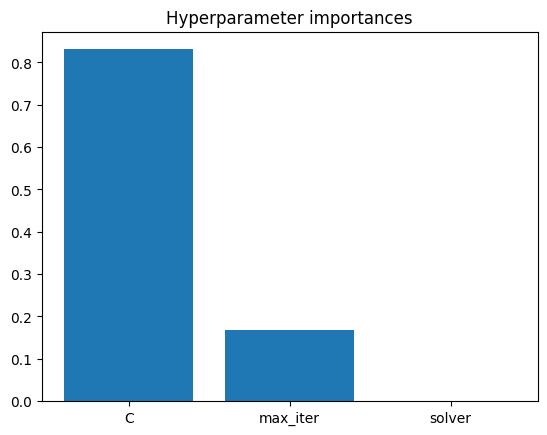

In [243]:
importances = optuna.importance.get_param_importances(study)
plt.bar(importances.keys(), importances.values())
plt.title('Hyperparameter importances')
plt.show()

<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** что вы видите и как вы прокомментируете, какие параметры важнее всего?

**Ответ:**

C - регуляризация оказалась важнее всего. max_iter - как писалось выше - неявная регуляризация, поэтому тоже играет роль. При этом солвер влияет меньше всего, так как  с простой логрег моделью в целом любой солвер должен достаточно хорошо сходиться.

</div>

#### **Задание 3.3. Заключение** (0.25 балла)

Фуух, много конечно, ну да так уж вышло, что теперь делать, данные это всегда геморрой. Напоследок:

1. Зафиксируйте оптимальный набор гиперпараметров. 
2. Сохраните либо модель, либо pipeline для будущего себя в части advanced. 
3. Сделайте тестовый submission на [Kaggle](https://www.kaggle.com/t/6fd940fbeb1746a78031e5d0277f6105), если ещё не.

In [244]:
import joblib

X = matches_df_train[['region_encoded', 'sqrt_avg_mmr', 'is_nan_mmr'] + encoder.columns].copy()
X_test = matches_df_test[['region_encoded', 'sqrt_avg_mmr', 'is_nan_mmr'] + encoder.columns].copy()
y = matches_df_train['radiant_win']

model = LogisticRegression(**study.best_params, random_state=52)
model.fit(X, y)

joblib.dump(model, 'best_model.joblib')

preds = model.predict_proba(X_test)[:, 1]

result = matches_df_test[['match_id']].copy()
result['Value'] = preds
result = result.rename(columns={'match_id': 'ID'})
result.to_csv('submission.csv', index=False)
